In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("scikit-rf:", rf.__version__)

Python: /Users/lgsus/Desktop/TWPA/.venv/bin/python3.12
NumPy: 1.26.4
scikit-rf: 2.0.1


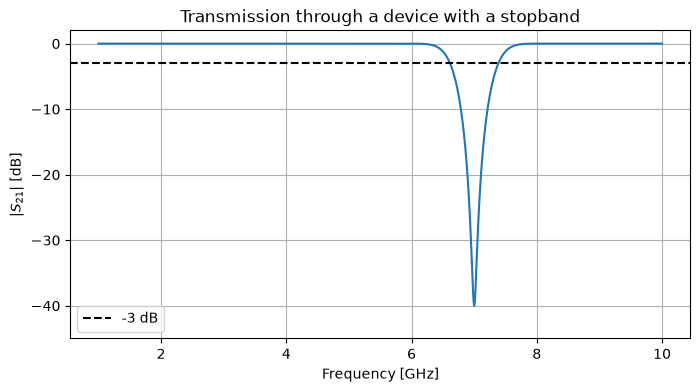

In [2]:
frequency_ghz = np.linspace(1, 10, 1000)

stopband_center = 7.0
stopband_width = 0.35

s21_magnitude = 1 - 0.99 * np.exp(
    -((frequency_ghz - stopband_center) / stopband_width) ** 2
)

s21_magnitude = np.maximum(s21_magnitude, 1e-12)
s21_db = 20 * np.log10(s21_magnitude)

plt.figure(figsize=(8, 4))
plt.plot(frequency_ghz, s21_db)
plt.axhline(-3, color="black", linestyle="--", label="-3 dB")
plt.xlabel("Frequency [GHz]")
plt.ylabel("$|S_{21}|$ [dB]")
plt.title("Transmission through a device with a stopband")
plt.ylim(-45, 2)
plt.grid()
plt.legend()
plt.show()

In [3]:
test_frequencies = [2.0, 6.5, 7.0, 7.5, 9.0]

for frequency in test_frequencies:
    index = np.argmin(np.abs(frequency_ghz - frequency))

    amplitude = s21_magnitude[index]
    power_fraction = amplitude**2
    transmission_db = s21_db[index]

    print(
        f"{frequency:3.1f} GHz: "
        f"amplitude={amplitude:.3f}, "
        f"power={100 * power_fraction:.3f}%, "
        f"S21={transmission_db:.1f} dB"
    )

2.0 GHz: amplitude=1.000, power=100.000%, S21=0.0 dB
6.5 GHz: amplitude=0.876, power=76.745%, S21=-1.1 dB
7.0 GHz: amplitude=0.010, power=0.010%, S21=-40.0 dB
7.5 GHz: amplitude=0.867, power=75.096%, S21=-1.2 dB
9.0 GHz: amplitude=1.000, power=100.000%, S21=-0.0 dB


# Step 2: Build an artificial transmission line

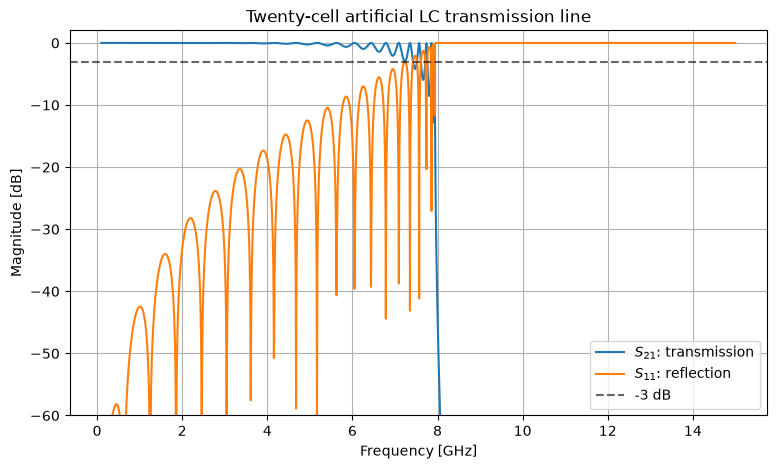

Approximate cutoff frequency: 7.957747154594766 GHz


In [4]:
# ============================================================
# 1. DEFINE THE FREQUENCIES WE WANT TO TEST
# ============================================================

# Create 2,000 equally spaced frequencies between:
#   0.1 GHz = 0.1 × 10^9 Hz
#   15 GHz  = 15 × 10^9 Hz
#
# Computers and equations normally use Hz, not GHz.
frequency_hz = np.linspace(0.1e9, 15e9, 2000)

# Create a second version in GHz for the graph.
# This changes only the displayed units.
frequency_ghz = frequency_hz / 1e9

# Electrical equations often use angular frequency:
#
#     omega = 2 × pi × frequency
#
# omega is measured in radians per second.
omega = 2 * np.pi * frequency_hz


# ============================================================
# 2. DEFINE ONE LC TRANSMISSION-LINE CELL
# ============================================================

# Inductance of one cell:
#
#   2e-9 H = 2 × 10^-9 H = 2 nanohenries
inductance = 2e-9

# Capacitance of one cell:
#
#   0.8e-12 F = 0.8 × 10^-12 F = 0.8 picofarads
capacitance = 0.8e-12

# Number of identical cells connected in a chain.
number_of_cells = 20

# The source, cables, and measurement instruments are assumed
# to have a characteristic impedance of 50 ohms.
reference_impedance = 50.0


# ============================================================
# 3. PREPARE ARRAYS FOR THE RESULTS
# ============================================================

# We want one S11 result and one S21 result for every frequency.
#
# The results will be complex numbers because microwave signals
# have both:
#   - magnitude
#   - phase
#
# dtype=complex tells NumPy that these arrays will contain
# complex numbers.
s11 = np.zeros(len(frequency_hz), dtype=complex)
s21 = np.zeros(len(frequency_hz), dtype=complex)


# ============================================================
# 4. CALCULATE THE CIRCUIT RESPONSE AT EVERY FREQUENCY
# ============================================================

# enumerate(omega) gives us two things on every loop:
#
#   index = position in the array: 0, 1, 2, 3, ...
#   w     = angular frequency at that position
#
# We calculate a separate circuit matrix at every frequency
# because inductors and capacitors behave differently as
# frequency changes.
for index, w in enumerate(omega):

    # --------------------------------------------------------
    # 4A. CALCULATE THE IMPEDANCE AND ADMITTANCE
    # --------------------------------------------------------

    # The impedance of an inductor is:
    #
    #     Z_L = j × omega × L
    #
    # Python writes the imaginary number j as "1j".
    #
    # Our cell uses half of the inductor before the capacitor
    # and half after it, so each part has inductance L/2.
    half_inductor_impedance = 1j * w * inductance / 2

    # The admittance of a capacitor is:
    #
    #     Y_C = j × omega × C
    #
    # Admittance is the inverse of impedance:
    #
    #     Y = 1 / Z
    capacitor_admittance = 1j * w * capacitance


    # --------------------------------------------------------
    # 4B. CREATE THE ABCD MATRIX FOR HALF AN INDUCTOR
    # --------------------------------------------------------

    # The ABCD matrix of a series impedance Z is:
    #
    #         [ 1  Z ]
    #         [ 0  1 ]
    #
    # Here, Z is the impedance of half the cell's inductor.
    half_inductor_matrix = np.array(
        [
            [1, half_inductor_impedance],
            [0, 1],
        ],
        dtype=complex,
    )


    # --------------------------------------------------------
    # 4C. CREATE THE ABCD MATRIX FOR THE CAPACITOR
    # --------------------------------------------------------

    # The ABCD matrix of a shunt admittance Y is:
    #
    #         [ 1  0 ]
    #         [ Y  1 ]
    #
    # "Shunt" means the capacitor is connected between
    # the transmission line and ground.
    capacitor_matrix = np.array(
        [
            [1, 0],
            [capacitor_admittance, 1],
        ],
        dtype=complex,
    )


    # --------------------------------------------------------
    # 4D. COMBINE THE PARTS INTO ONE COMPLETE CELL
    # --------------------------------------------------------

    # One cell is:
    #
    #     half inductor -> capacitor -> half inductor
    #
    # The @ symbol means matrix multiplication.
    #
    # Matrix multiplication combines circuit blocks that are
    # connected one after another.
    cell_matrix = (
        half_inductor_matrix
        @ capacitor_matrix
        @ half_inductor_matrix
    )


    # --------------------------------------------------------
    # 4E. REPEAT THE CELL MANY TIMES
    # --------------------------------------------------------

    # Connecting 20 identical cells means multiplying the same
    # cell matrix by itself 20 times:
    #
    #     total = cell × cell × cell × ... × cell
    #
    # matrix_power performs that repeated multiplication.
    complete_line_matrix = np.linalg.matrix_power(
        cell_matrix,
        number_of_cells,
    )


    # --------------------------------------------------------
    # 4F. EXTRACT A, B, C, AND D FROM THE MATRIX
    # --------------------------------------------------------

    # The complete matrix has this form:
    #
    #         [ A  B ]
    #         [ C  D ]
    #
    # Python array positions begin at zero:
    #
    #   [0, 0] = first row, first column
    #   [0, 1] = first row, second column
    #   [1, 0] = second row, first column
    #   [1, 1] = second row, second column
    A = complete_line_matrix[0, 0]
    B = complete_line_matrix[0, 1]
    C_abcd = complete_line_matrix[1, 0]
    D = complete_line_matrix[1, 1]


    # --------------------------------------------------------
    # 4G. CONVERT ABCD PARAMETERS INTO S-PARAMETERS
    # --------------------------------------------------------

    # ABCD parameters are convenient for combining circuit cells.
    # S-parameters are convenient for describing microwave
    # transmission and reflection.
    #
    # This is the common denominator in both conversion equations.
    denominator = (
        A
        + B / reference_impedance
        + C_abcd * reference_impedance
        + D
    )

    # S21 describes transmission from Port 1 to Port 2.
    s21[index] = 2 / denominator

    # S11 describes reflection back from Port 1.
    s11[index] = (
        A
        + B / reference_impedance
        - C_abcd * reference_impedance
        - D
    ) / denominator


# ============================================================
# 5. CONVERT S-PARAMETER MAGNITUDES INTO DECIBELS
# ============================================================

# np.abs(s21) removes the phase and keeps the magnitude.
s21_magnitude = np.abs(s21)
s11_magnitude = np.abs(s11)

# Convert amplitude ratios into decibels:
#
#     dB = 20 × log10(amplitude ratio)
#
# np.maximum prevents log10(0), which is mathematically
# negative infinity and can produce warnings.
s21_db = 20 * np.log10(
    np.maximum(s21_magnitude, 1e-12)
)

s11_db = 20 * np.log10(
    np.maximum(s11_magnitude, 1e-12)
)


# ============================================================
# 6. PLOT THE RESULTS
# ============================================================

# Create a graph that is 9 inches wide and 5 inches high.
plt.figure(figsize=(9, 5))

# Plot transmission.
plt.plot(
    frequency_ghz,
    s21_db,
    label="$S_{21}$: transmission",
)

# Plot reflection.
plt.plot(
    frequency_ghz,
    s11_db,
    label="$S_{11}$: reflection",
)

# Add a horizontal line at -3 dB.
# At -3 dB, half of the input power is transmitted.
plt.axhline(
    -3,
    color="black",
    linestyle="--",
    alpha=0.6,
    label="-3 dB",
)

# Describe the axes and graph.
plt.xlabel("Frequency [GHz]")
plt.ylabel("Magnitude [dB]")
plt.title("Twenty-cell artificial LC transmission line")

# Display only values between -60 dB and +2 dB.
plt.ylim(-60, 2)

# Add background grid lines.
plt.grid()

# Display the curve labels.
plt.legend()

# Display the completed graph.
plt.show()


# ============================================================
# 7. CALCULATE THE APPROXIMATE CUTOFF FREQUENCY
# ============================================================

# For this artificial LC transmission line:
#
#     cutoff frequency ≈ 1 / (pi × sqrt(L × C))
cutoff_hz = 1 / (
    np.pi * np.sqrt(inductance * capacitance)
)

print(
    "Approximate cutoff frequency:",
    cutoff_hz / 1e9,
    "GHz",
)

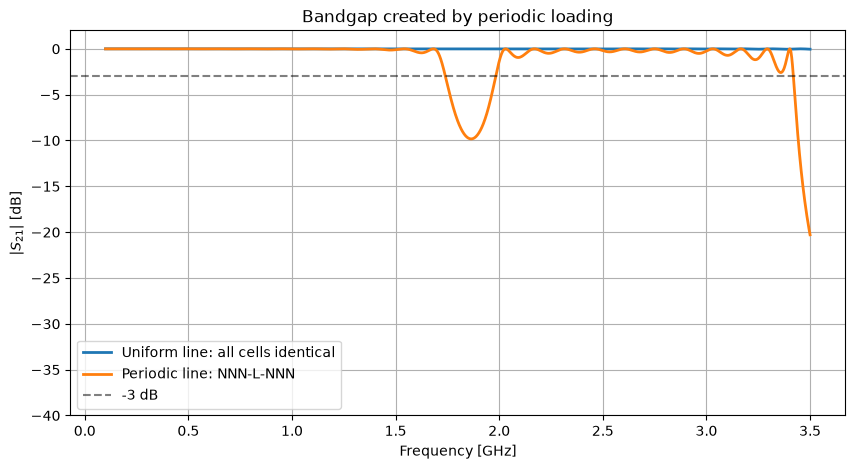

In [5]:
# ============================================================
# 1. SELECT THE FREQUENCY RANGE
# ============================================================

# We only plot frequencies from 0.1 to 3.5 GHz.
#
# The ordinary LC line has its main cutoff near 8 GHz, which
# is outside this plot. This lets us focus on the new bandgap
# created by periodic loading.
frequency_hz = np.linspace(0.1e9, 3.5e9, 2000)

# Convert Hz to GHz for the graph.
frequency_ghz = frequency_hz / 1e9

# Convert ordinary frequency f into angular frequency:
#
#     omega = 2 × pi × f
omega = 2 * np.pi * frequency_hz


# ============================================================
# 2. DEFINE THE CELL PARAMETERS
# ============================================================

# Both normal and loaded cells use the same inductance.
inductance = 2e-9  # 2 nH

# A normal cell has 0.8 pF capacitance.
normal_capacitance = 0.8e-12

# A loaded cell has a different capacitance.
#
# This difference causes the loaded cell to have a different
# impedance and phase response from a normal cell.
loaded_capacitance = 0.3e-12

# Each supercell will look like:
#
#     normal, normal, loaded, normal, normal
#
# Therefore, there are two normal cells on each side.
normal_cells_per_side = 3

# Repeat the supercell twelve times.
number_of_supercells = 12

# One supercell contains:
#
#     2 normal + 1 loaded + 2 normal = 5 cells
cells_per_supercell = 7

# Both the uniform and periodic lines will contain 60 cells.
total_number_of_cells = (
    cells_per_supercell * number_of_supercells
)

# Reference impedance of the source and measurement system.
reference_impedance = 50.0


# ============================================================
# 3. DEFINE A FUNCTION THAT CREATES ONE LC CELL
# ============================================================

# A function lets us reuse the same calculation for cells
# with different capacitance values.
#
# The function receives:
#   w = angular frequency
#   L = cell inductance
#   C = cell capacitance
#
# It returns the 2 × 2 ABCD matrix of that cell.
def create_lc_cell(w, L, C):

    # Impedance of half the cell's series inductor:
    #
    #     Z = j × omega × L/2
    half_inductor_impedance = 1j * w * L / 2

    # Admittance of the shunt capacitor:
    #
    #     Y = j × omega × C
    capacitor_admittance = 1j * w * C

    # ABCD matrix of a series impedance.
    half_inductor_matrix = np.array(
        [
            [1, half_inductor_impedance],
            [0, 1],
        ],
        dtype=complex,
    )

    # ABCD matrix of a shunt admittance.
    capacitor_matrix = np.array(
        [
            [1, 0],
            [capacitor_admittance, 1],
        ],
        dtype=complex,
    )

    # Combine:
    #
    #     half inductor -> capacitor -> half inductor
    cell_matrix = (
        half_inductor_matrix
        @ capacitor_matrix
        @ half_inductor_matrix
    )

    # Send the completed matrix back to the main program.
    return cell_matrix


# ============================================================
# 4. DEFINE A FUNCTION THAT CALCULATES S21
# ============================================================

# This function converts a complete ABCD matrix into S21.
#
# It receives:
#   matrix = ABCD matrix of the complete transmission line
#   Z0     = reference impedance
#
# It returns:
#   S21 = complex transmission amplitude
def calculate_s21(matrix, Z0):

    # Extract the four elements from:
    #
    #         [ A  B ]
    #         [ C  D ]
    A = matrix[0, 0]
    B = matrix[0, 1]
    C_abcd = matrix[1, 0]
    D = matrix[1, 1]

    # Denominator in the ABCD-to-S21 conversion.
    denominator = A + B / Z0 + C_abcd * Z0 + D

    # Calculate and return S21.
    return 2 / denominator


# ============================================================
# 5. PREPARE ARRAYS FOR THE TWO TRANSMISSION LINES
# ============================================================

# S21 of the uniform line.
uniform_s21 = np.zeros(
    len(frequency_hz),
    dtype=complex,
)

# S21 of the periodically loaded line.
periodic_s21 = np.zeros(
    len(frequency_hz),
    dtype=complex,
)


# ============================================================
# 6. CALCULATE BOTH LINES AT EVERY FREQUENCY
# ============================================================

for index, w in enumerate(omega):

    # --------------------------------------------------------
    # 6A. CREATE THE TWO TYPES OF CELLS
    # --------------------------------------------------------

    # Normal cell.
    normal_cell = create_lc_cell(
        w,
        inductance,
        normal_capacitance,
    )

    # Loaded cell.
    loaded_cell = create_lc_cell(
        w,
        inductance,
        loaded_capacitance,
    )


    # --------------------------------------------------------
    # 6B. BUILD THE UNIFORM LINE
    # --------------------------------------------------------

    # The uniform line contains 60 normal cells:
    #
    #     N N N N N N N N ... N
    uniform_line = np.linalg.matrix_power(
        normal_cell,
        total_number_of_cells,
    )


    # --------------------------------------------------------
    # 6C. BUILD ONE PERIODIC SUPERCELL
    # --------------------------------------------------------

    # Two normal cells on the left:
    #
    #     N N
    normal_left = np.linalg.matrix_power(
        normal_cell,
        normal_cells_per_side,
    )

    # Two normal cells on the right:
    #
    #     N N
    normal_right = np.linalg.matrix_power(
        normal_cell,
        normal_cells_per_side,
    )

    # Create one supercell:
    #
    #     N N L N N
    #
    # The @ symbol connects these circuit sections in sequence.
    supercell = (
        normal_left
        @ loaded_cell
        @ normal_right
    )


    # --------------------------------------------------------
    # 6D. REPEAT THE SUPERCELL
    # --------------------------------------------------------

    # Repeat the five-cell pattern twelve times:
    #
    #     NN L NN | NN L NN | NN L NN | ...
    periodic_line = np.linalg.matrix_power(
        supercell,
        number_of_supercells,
    )


    # --------------------------------------------------------
    # 6E. CALCULATE TRANSMISSION THROUGH BOTH LINES
    # --------------------------------------------------------

    uniform_s21[index] = calculate_s21(
        uniform_line,
        reference_impedance,
    )

    periodic_s21[index] = calculate_s21(
        periodic_line,
        reference_impedance,
    )


# ============================================================
# 7. CONVERT THE RESULTS INTO DECIBELS
# ============================================================

uniform_s21_db = 20 * np.log10(
    np.maximum(np.abs(uniform_s21), 1e-12)
)

periodic_s21_db = 20 * np.log10(
    np.maximum(np.abs(periodic_s21), 1e-12)
)


# ============================================================
# 8. PLOT THE COMPARISON
# ============================================================

plt.figure(figsize=(10, 5))

# Uniform transmission line.
plt.plot(
    frequency_ghz,
    uniform_s21_db,
    label="Uniform line: all cells identical",
    linewidth=2,
)

# Periodically loaded transmission line.
plt.plot(
    frequency_ghz,
    periodic_s21_db,
    label="Periodic line: NNN-L-NNN",
    linewidth=2,
)

# Add the -3 dB reference.
plt.axhline(
    -3,
    color="black",
    linestyle="--",
    alpha=0.5,
    label="-3 dB",
)

plt.xlabel("Frequency [GHz]")
plt.ylabel("$|S_{21}|$ [dB]")
plt.title("Bandgap created by periodic loading")
plt.ylim(-40, 2)
plt.grid()
plt.legend()
plt.show()

In [6]:
# ============================================================
# MEASURE ONLY THE MAIN BANDGAP
# ============================================================

# Select a frequency window containing the main bandgap.
#
# The condition produces an array of True/False values:
#
#   True  when frequency is between 1.5 and 2.2 GHz
#   False everywhere else
main_gap_window = (
    (frequency_ghz >= 1.5)
    & (frequency_ghz <= 2.2)
)

# Extract only the frequencies inside that window.
gap_frequency = frequency_ghz[main_gap_window]

# Extract the corresponding S21 values.
gap_s21_db = periodic_s21_db[main_gap_window]


# Find the array position containing the lowest S21.
minimum_index = np.argmin(gap_s21_db)

# Use that position to obtain the frequency and transmission.
center_frequency = gap_frequency[minimum_index]
minimum_transmission = gap_s21_db[minimum_index]

print(
    f"Bandgap center: {center_frequency:.3f} GHz"
)

print(
    f"Minimum transmission: {minimum_transmission:.1f} dB"
)


# Find points inside this window where S21 is below -3 dB.
below_minus_3_db = gap_s21_db < -3

# Extract their frequencies.
frequencies_below_minus_3_db = gap_frequency[
    below_minus_3_db
]

if len(frequencies_below_minus_3_db) > 0:

    lower_edge = frequencies_below_minus_3_db[0]
    upper_edge = frequencies_below_minus_3_db[-1]
    width = upper_edge - lower_edge

    print(f"Lower -3 dB edge: {lower_edge:.3f} GHz")
    print(f"Upper -3 dB edge: {upper_edge:.3f} GHz")
    print(f"-3 dB bandgap width: {width:.3f} GHz")

else:

    print("No bandgap below -3 dB was found.")

Bandgap center: 1.865 GHz
Minimum transmission: -9.8 dB
Lower -3 dB edge: 1.741 GHz
Upper -3 dB edge: 1.983 GHz
-3 dB bandgap width: 0.242 GHz


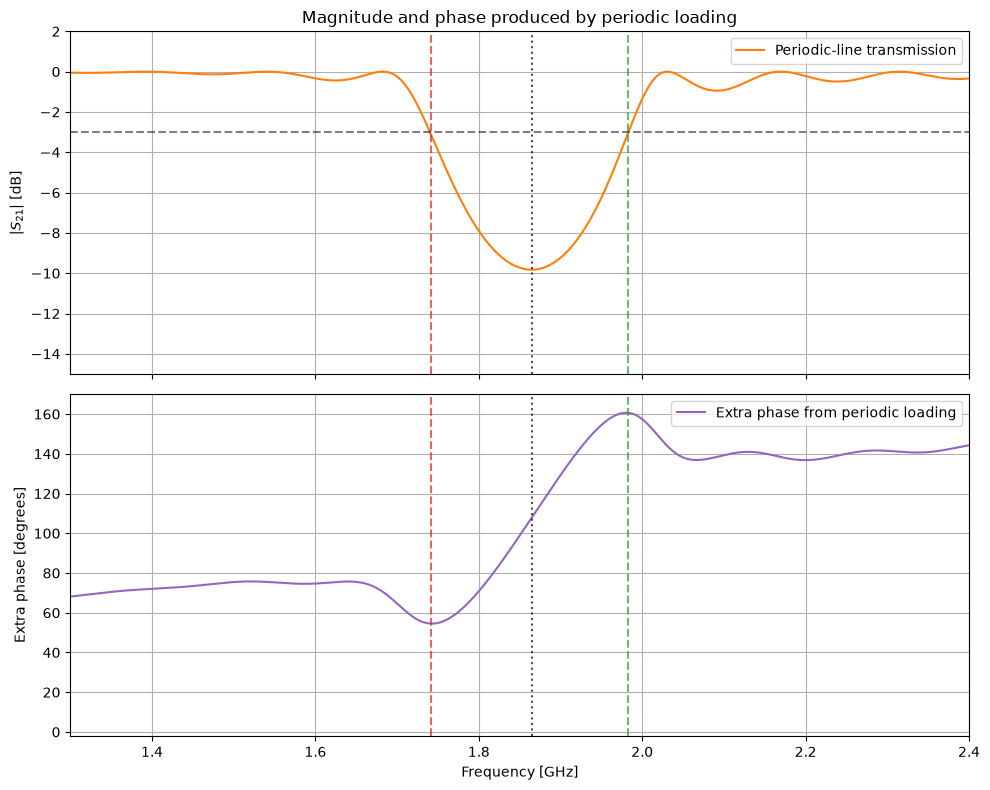

In [7]:
# ============================================================
# 1. EXTRACT THE PHASE OF S21
# ============================================================

# S21 is a complex number:
#
#     S21 = magnitude × exp(j × phase)
#
# np.angle() extracts the phase angle in radians.
uniform_phase_rad = np.angle(uniform_s21)
periodic_phase_rad = np.angle(periodic_s21)


# ============================================================
# 2. REMOVE ARTIFICIAL 360-DEGREE JUMPS
# ============================================================

# Phase is normally reported between -pi and +pi.
#
# Consequently, a continuously decreasing phase can appear to
# jump suddenly from -pi to +pi:
#
#   ... -170°, -175°, -179°, +179°, +175° ...
#
# np.unwrap() removes those artificial jumps and reconstructs
# a continuous phase curve.
uniform_phase_unwrapped = np.unwrap(
    uniform_phase_rad
)

periodic_phase_unwrapped = np.unwrap(
    periodic_phase_rad
)


# ============================================================
# 3. CALCULATE THE EXTRA PHASE CAUSED BY PERIODIC LOADING
# ============================================================

# Both simulated lines contain the same total number of cells.
#
# Subtracting their phases approximately removes the ordinary
# propagation phase and leaves the additional phase produced
# by the periodic loading.
extra_phase_rad = (
    periodic_phase_unwrapped
    - uniform_phase_unwrapped
)

# Convert radians into degrees:
#
#     degrees = radians × 180/pi
extra_phase_deg = np.rad2deg(extra_phase_rad)


# ============================================================
# 4. PLOT MAGNITUDE AND EXTRA PHASE TOGETHER
# ============================================================

# Create one figure containing two vertically arranged graphs.
#
# sharex=True means both graphs use the same frequency axis.
figure, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
)


# ------------------------------------------------------------
# TOP GRAPH: TRANSMISSION MAGNITUDE
# ------------------------------------------------------------

axes[0].plot(
    frequency_ghz,
    periodic_s21_db,
    color="tab:orange",
    label="Periodic-line transmission",
)

axes[0].axhline(
    -3,
    color="black",
    linestyle="--",
    alpha=0.5,
)

axes[0].set_ylabel("$|S_{21}|$ [dB]")
axes[0].set_title(
    "Magnitude and phase produced by periodic loading"
)
axes[0].set_ylim(-15, 2)
axes[0].grid()
axes[0].legend()


# ------------------------------------------------------------
# BOTTOM GRAPH: ADDITIONAL PHASE
# ------------------------------------------------------------

axes[1].plot(
    frequency_ghz,
    extra_phase_deg,
    color="tab:purple",
    label="Extra phase from periodic loading",
)

axes[1].set_xlabel("Frequency [GHz]")
axes[1].set_ylabel("Extra phase [degrees]")
axes[1].grid()
axes[1].legend()


# ------------------------------------------------------------
# MARK THE MEASURED BANDGAP
# ------------------------------------------------------------

# Add a vertical line at the lower edge, center, and upper edge
# of the bandgap on both graphs.
for axis in axes:

    axis.axvline(
        lower_edge,
        color="tab:red",
        linestyle="--",
        alpha=0.7,
        label="Lower edge",
    )

    axis.axvline(
        center_frequency,
        color="black",
        linestyle=":",
        alpha=0.7,
        label="Bandgap center",
    )

    axis.axvline(
        upper_edge,
        color="tab:green",
        linestyle="--",
        alpha=0.7,
        label="Upper edge",
    )


# Focus on the main bandgap and its surrounding frequencies.
axes[1].set_xlim(1.3, 2.4)

# Prevent labels from overlapping.
plt.tight_layout()

# Display the graphs.
plt.show()